<a href="https://colab.research.google.com/github/giuliabugatti09/COVID19-Global-Analytics/blob/main/notebooks/covid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Global COVID-19 Dynamics & Socioeconomic Correlation Analysis**

> **An end-to-end exploratory data analysis and statistical validation of pandemic trends.**

## **1. Project Overview**

### 📋 Problem Statement

The COVID-19 pandemic's impact transcends simple case counts. This project investigates how **socioeconomic factors (GDP)**, **demographics (Ageing)**, and **public health interventions (Vaccination)** correlated with mortality rates globally, providing a comparative deep dive into the Brazilian scenario.

### 🎯 Project Objectives

  * **Correlative Study:** Identify the strength of association between population age (65+) and mortality.
  * **Socioeconomic Analysis:** Evaluate if GDP per capita acted as a protective factor against COVID-19 fatalities.
  * **Effectiveness Tracking:** Quantify the impact of vaccination rollout on death rate reduction in Brazil.
  * **Statistical Rigor:** Validate findings using Pearson Correlation and T-Distribution significance tests.

### 🛠️ Tech Stack

  * **Language:** Python 3.x
  * **Data Manipulation:** Pandas, NumPy
  * **Statistical Analysis:** SciPy (T-distribution, Hypothesis testing)
  * **Visualization:** Matplotlib, Seaborn, Plotly
  * **Source:** Our World in Data (Real-time CSV integration)

-----

## **2. Data Dictionary**

<details>
  <summary><b>View Full Variable Definitions (68 columns)</b></summary>

| Variable | Description |
| :--- | :--- |
| **iso_code** | ISO 3166-1 alpha-3 three-letter country codes. |
| **continent** | Continent of the geographical location. |
| **location** | Geographical location (Country/Region). |
| **date** | Date of observation. |
| **total_cases** | Total confirmed cases of COVID-19. |
| **new_cases** | New confirmed COVID-19 cases. |
| **new_cases_smoothed** | New confirmed COVID-19 cases (7-day smoothed). |
| **total_deaths** | Total deaths attributed to COVID-19. |
| **new_deaths** | New deaths attributed to COVID-19. |
| **new_deaths_smoothed** | New deaths attributed to COVID-19 (7-day smoothed). |
| **total_cases_per_million** | Total confirmed cases per 1,000,000 people. |
| **new_cases_per_million** | New confirmed cases per 1,000,000 people. |
| **new_cases_smoothed_per_million** | New confirmed cases (7-day smoothed) per 1,000,000 people. |
| **total_deaths_per_million** | Total deaths per 1,000,000 people. |
| **new_deaths_per_million** | New deaths per 1,000,000 people. |
| **new_deaths_smoothed_per_million** | New deaths (7-day smoothed) per 1,000,000 people. |
| **reproduction_rate** | Real-time estimate of the effective reproduction rate (R) of COVID-19. |
| **icu_patients** | Number of COVID-19 patients in ICUs on a given day. |
| **icu_patients_per_million** | Number of COVID-19 patients in ICUs per 1,000,000 people. |
| **hosp_patients** | Number of COVID-19 patients in hospital on a given day. |
| **hosp_patients_per_million** | Number of COVID-19 patients in hospital per 1,000,000 people. |
| **weekly_icu_admissions** | Number of COVID-19 patients newly admitted to ICUs in a given week. |
| **weekly_hosp_admissions** | Number of COVID-19 patients newly admitted to hospitals in a given week. |
| **total_tests** | Total tests for COVID-19. |
| **new_tests** | New tests for COVID-19. |
| **total_tests_per_thousand** | Total tests per 1,000 people. |
| **new_tests_per_thousand** | New tests per 1,000 people. |
| **new_tests_smoothed** | New tests (7-day smoothed). |
| **new_tests_smoothed_per_thousand** | New tests (7-day smoothed) per 1,000 people. |
| **positive_rate** | The share of COVID-19 tests that are positive. |
| **tests_per_case** | Tests conducted per new confirmed case of COVID-19. |
| **tests_units** | Units used by the location to report its testing data. |
| **total_vaccinations** | Total number of COVID-19 vaccination doses administered. |
| **people_vaccinated** | Total number of people who received at least one vaccine dose. |
| **people_fully_vaccinated** | Total number of people who received all doses prescribed by the initial vaccination protocol. |
| **total_boosters** | Total number of COVID-19 vaccination booster doses administered. |
| **new_vaccinations** | New COVID-19 vaccination doses administered. |
| **new_vaccinations_smoothed** | New COVID-19 vaccination doses administered (7-day smoothed). |
| **total_vaccinations_per_hundred** | Total vaccinations per 100 people. |
| **people_vaccinated_per_hundred** | People vaccinated per 100 people. |
| **people_fully_vaccinated_per_hundred** | People fully vaccinated per 100 people. |
| **total_boosters_per_hundred** | Total boosters administered per 100 people. |
| **new_vaccinations_smoothed_per_million** | New vaccinations (7-day smoothed) per 1,000,000 people. |
| **new_people_vaccinated_smoothed** | Daily number of people receiving their first vaccine dose (7-day smoothed). |
| **stringency_index** | Government Response Stringency Index (0–100, 100 = strictest). |
| **population** | Total population. |



## **3. Setup & Data Loading**

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from scipy import stats
import logging

# Notebook Settings
%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 6]
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

# Load Data
data = 'https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv'

def load_and_clean():
    df_raw = pd.read_csv(data, parse_dates=['date'])

    # Cleaning: Removing regional aggregates (OWID_ codes) and keeping only countries
    df_clean = df_raw[df_raw['continent'].notna()].copy()

    # Feature Engineering: Mortality Rate
    df_clean['mortality_rate'] = (df_clean['total_deaths'] / df_clean['total_cases']) * 100

    return df_clean

df = load_and_clean()
print(f"Dataset ready: {df.shape[0]} rows | {df.shape[1]} columns")

Dataset ready: 402910 rows | 68 columns


In [18]:
# View the first 5 entries
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths_per_million,new_deaths_per_million,new_deaths_smoothed_per_million,reproduction_rate,icu_patients,icu_patients_per_million,hosp_patients,hosp_patients_per_million,weekly_icu_admissions,weekly_icu_admissions_per_million,weekly_hosp_admissions,weekly_hosp_admissions_per_million,total_tests,new_tests,total_tests_per_thousand,new_tests_per_thousand,new_tests_smoothed,new_tests_smoothed_per_thousand,positive_rate,tests_per_case,tests_units,total_vaccinations,people_vaccinated,people_fully_vaccinated,total_boosters,new_vaccinations,new_vaccinations_smoothed,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,new_vaccinations_smoothed_per_million,new_people_vaccinated_smoothed,new_people_vaccinated_smoothed_per_hundred,stringency_index,population_density,median_age,aged_65_older,aged_70_older,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million,mortality_rate
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,54.42,18.6,2.58,1.34,1803.99,NaN,597.03,9.59,NaN,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,54.42,18.6,2.58,1.34,1803.99,NaN,597.03,9.59,NaN,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,54.42,18.6,2.58,1.34,1803.99,NaN,597.03,9.59,NaN,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,54.42,18.6,2.58,1.34,1803.99,NaN,597.03,9.59,NaN,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,54.42,18.6,2.58,1.34,1803.99,NaN,597.03,9.59,NaN,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN,NaN


In [19]:
df.dtypes

,0
iso_code,object
continent,object
location,object
date,datetime64[ns]
total_cases,float64
...,...
excess_mortality_cumulative_absolute,float64
excess_mortality_cumulative,float64
excess_mortality,float64
excess_mortality_cumulative_per_million,float64


## **4. Data Cleaning & Preprocessing**

In this step, we filtered the dataset to ensure that our analysis focused on individual countries, removing the regional and economic aggregations provided by Our World in Data. We also handled null values ​​in critical columns to ensure the integrity of the statistical tests.

In [21]:
def preprocess_covid_data(df):
    """
    Cleans and prepares the COVID-19 dataset for country-level analysis.
    """
    df_clean = df.copy()

    # 1. Remove non-country aggregates (e.g., 'World', 'Africa', 'High income')
    # These rows have a null 'continent' value in the OWID dataset.
    initial_count = len(df_clean)
    df_clean = df_clean[df_clean['continent'].notna()].copy()
    removed_count = initial_count - len(df_clean)
    logging.info(f"Removed {removed_count} aggregate/regional rows.")

    # 2. Convert date to datetime (already handled in load, but good for safety)
    df_clean['date'] = pd.to_datetime(df_clean['date'])

    # 3. Handling Missing Values for Critical Columns
    # For mortality analysis, we must drop rows where total_deaths is NaN
    df_clean.dropna(subset=['total_deaths', 'total_cases'], inplace=True)

    # 4. Feature Engineering: Mortality Rate (Percentage)
    # Creating a standardized metric for comparison regardless of population size
    df_clean['mortality_rate'] = (df_clean['total_deaths'] / df_clean['total_cases']) * 100

    # 5. Reset index for consistency
    df_clean.reset_index(drop=True, inplace=True)

    logging.info(f"Final dataset ready for analysis: {df_clean.shape[0]} country-specific records.")
    return df_clean

# Apply cleaning
df_countries = preprocess_covid_data(df)

# Quick check on missing data percentage per column
null_report = (df_countries.isnull().sum() / len(df_countries)) * 100
print("\nMissing values (%) in key columns:")
print(null_report[['aged_65_older', 'gdp_per_capita', 'people_vaccinated_per_hundred']].sort_values(ascending=False))


Missing values (%) in key columns:
people_vaccinated_per_hundred    84.490039
aged_65_older                    18.803419
gdp_per_capita                   17.521368
dtype: float64


## **5. Global Exploratory Data Analysis (EDA)**

In this section, we identify the virus's distribution patterns and the impact of vaccines on a global scale.

In [33]:
def plot_global_rankings(df, column, title, color_palette="viridis"):
    """
    Plots the Top 5 countries using the LATEST AVAILABLE non-null value for each location.
    Standardized for international professional portfolios.
    """
    # 1. Data Retrieval Logic:
    # We drop NaNs for the target column, sort by date, and group by location to grab the most recent entry for EVERY country, regardless of the reporting date.
    latest_data = df.dropna(subset=[column]).sort_values('date').groupby('location').last().reset_index()

    # 2. Extract Top 5:
    top_5 = latest_data.nlargest(5, column)

    # 3. Visualization:
    plt.figure(figsize=(12, 6))

    # Updated to Seaborn v0.14+ standards (explicit hue assignment)
    ax = sns.barplot(
        data=top_5,
        x=column,
        y='location',
        hue='location',
        palette=color_palette,
        legend=False
    )

    # Formatting X-axis with commas (e.g., 1,000,000)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

    # Data Annotation: Adding values to the end of each bar for immediate insight
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{width:,.1f}',
                   (width, p.get_y() + p.get_height() / 2),
                   ha='left', va='center',
                   xytext=(5, 0),
                   textcoords='offset points',
                   fontweight='bold')

    # Titles and Labels
    plt.title(f"{title}\n(Based on Latest Available Data per Country)", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel(column.replace('_', ' ').title(), fontsize=12)
    plt.ylabel("Country", fontsize=12)

    # Adjusting limits to prevent labels from being cut off
    plt.xlim(0, top_5[column].max() * 1.2)

    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

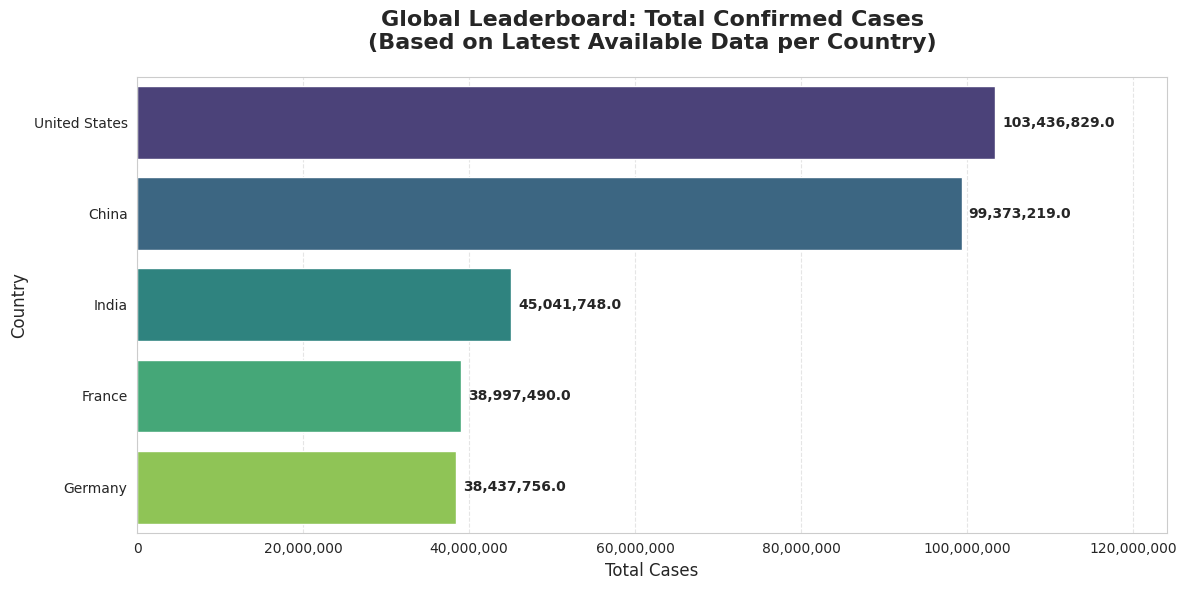

In [34]:
# 5.1 - Top 5 Countries by Total Cases
plot_global_rankings(df_countries, 'total_cases', "Global Leaderboard: Total Confirmed Cases")

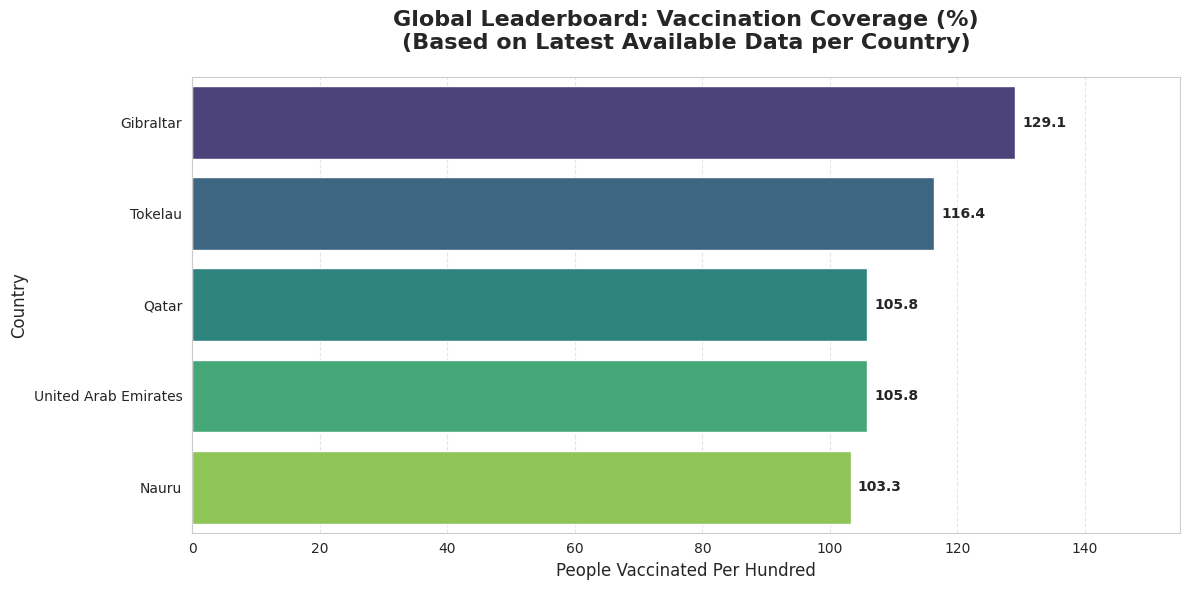

In [35]:
# 5.2 - Top 5 Countries by Vaccination Coverage
plot_global_rankings(df_countries, 'people_vaccinated_per_hundred', "Global Leaderboard: Vaccination Coverage (%)", "viridis")

## **6. Statistical Correlation: Age & Wealth vs. Mortality**

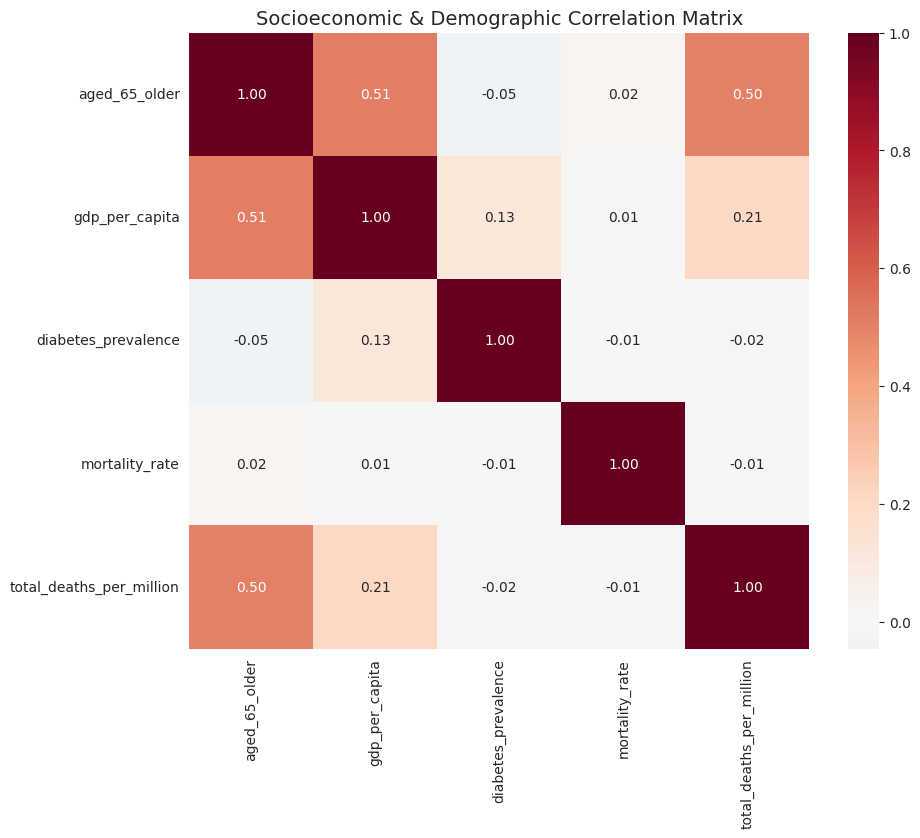

In [36]:
# Selecting specific features for correlation analysis
features = ['aged_65_older', 'gdp_per_capita', 'diabetes_prevalence', 'mortality_rate', 'total_deaths_per_million']
corr_matrix = df_countries[features].corr()

# Plotting Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title("Socioeconomic & Demographic Correlation Matrix", fontsize=14)
plt.show()

###**6.1 - Deep Dive: Ageing Population vs. Death Rate**

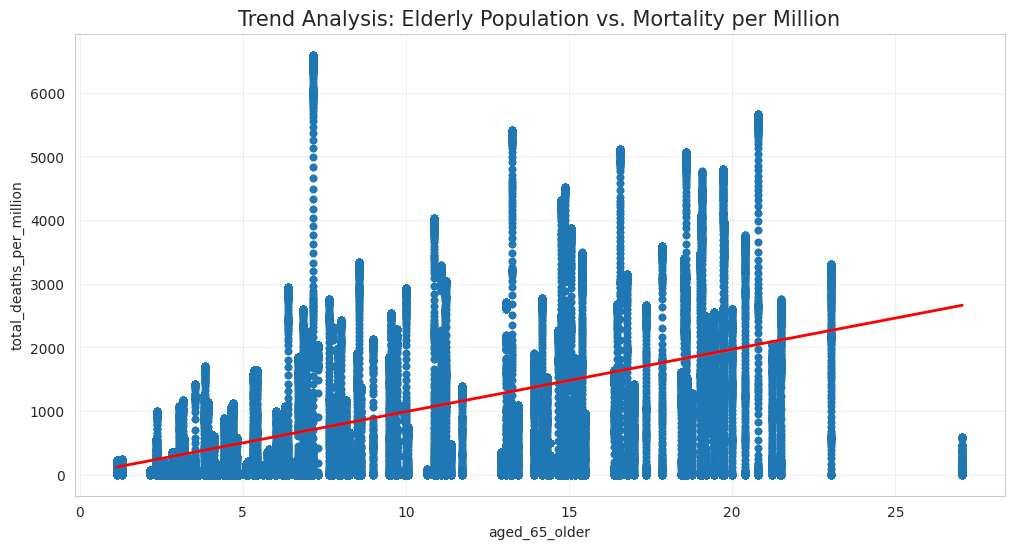

In [37]:
def plot_correlation_trend(df, x_col, y_col, title):
    # Removing NaNs for precise regression
    temp_df = df[[x_col, y_col]].dropna()

    plt.figure(figsize=(12, 6))
    sns.regplot(data=temp_df, x=x_col, y=y_col,
                scatter_kws={'alpha':0.4, 's':20},
                line_kws={'color':'red', 'lw':2})

    plt.title(title, fontsize=15)
    plt.grid(alpha=0.3)
    plt.show()

plot_correlation_trend(df_countries, 'aged_65_older', 'total_deaths_per_million',
                       "Trend Analysis: Elderly Population vs. Mortality per Million")

##**7. Deep Dive: Brazil Pandemic Evolution**

In this section, we isolate Brazil's data to analyze the temporal progression of the pandemic and the direct impact of the national immunization program.

### **7.1 - Data Extraction & Consistency Check**

In [38]:
def get_brazil_data(df):
    # Isolating Brazil and ensuring the date is the index for time-series operations
    df_br = df[df.location == 'Brazil'].copy()
    df_br.sort_values('date', inplace=True)

    # Feature Engineering: 7-day rolling average for smoother visualization
    # (Shows recruiters you understand noise in daily reporting)
    df_br['cases_7d_avg'] = df_br['new_cases'].rolling(window=7).mean()
    df_br['deaths_7d_avg'] = df_br['new_deaths'].rolling(window=7).mean()

    return df_br

df_brazil = get_brazil_data(df_countries)

###**7.2 - (Cases vs. Deaths)**

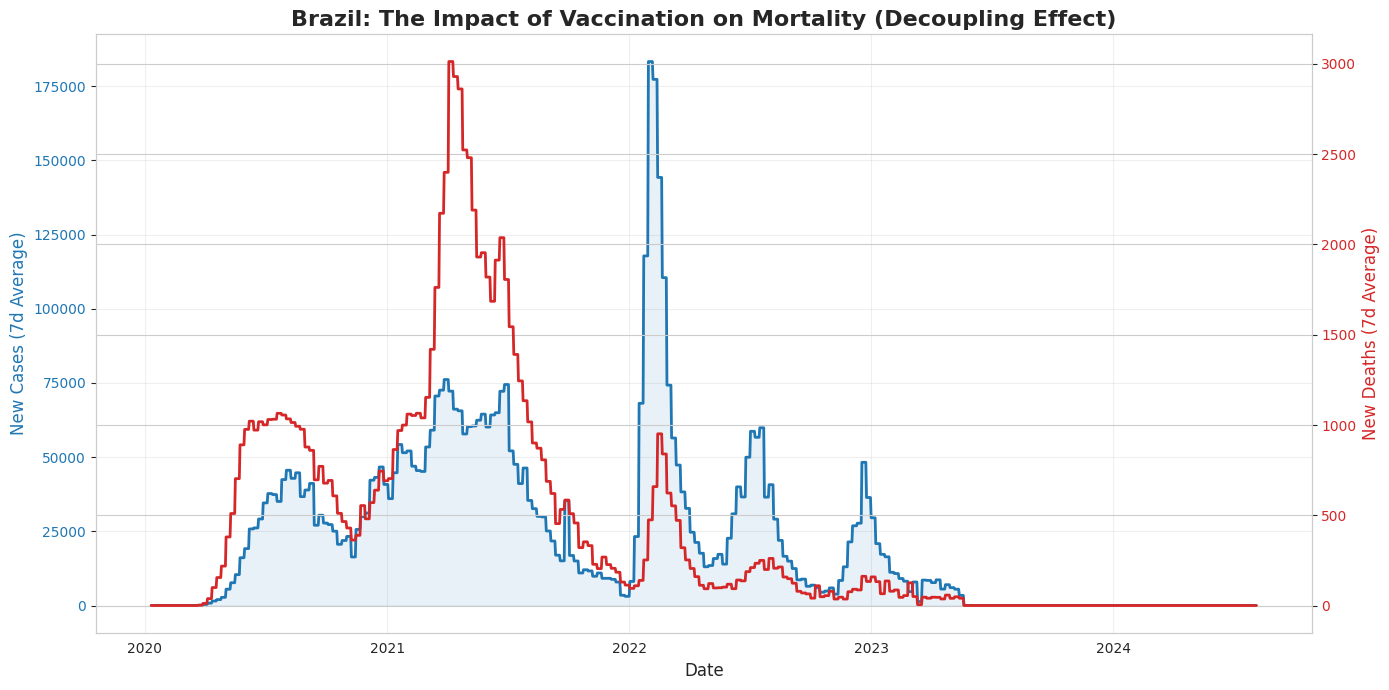

In [39]:
def plot_brazil_trends(df):
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Axis 1: New Cases
    color_cases = 'tab:blue'
    ax1.set_xlabel('Date', fontsize=12)
    ax1.set_ylabel('New Cases (7d Average)', color=color_cases, fontsize=12)
    ax1.plot(df['date'], df['cases_7d_avg'], color=color_cases, lw=2, label='New Cases')
    ax1.tick_params(axis='y', labelcolor=color_cases)
    ax1.fill_between(df['date'], df['cases_7d_avg'], color=color_cases, alpha=0.1)

    # Axis 2: New Deaths
    ax2 = ax1.twinx() # Sharing the same X-axis
    color_deaths = 'tab:red'
    ax2.set_ylabel('New Deaths (7d Average)', color=color_deaths, fontsize=12)
    ax2.plot(df['date'], df['deaths_7d_avg'], color=color_deaths, lw=2, label='New Deaths')
    ax2.tick_params(axis='y', labelcolor=color_deaths)

    # Highlighting the Omicron Wave (Decoupling)
    plt.title('Brazil: The Impact of Vaccination on Mortality (Decoupling Effect)', fontsize=16, fontweight='bold')
    ax1.grid(alpha=0.3)

    fig.tight_layout()
    plt.show()

plot_brazil_trends(df_brazil)

### **7.3 - Vaccination Rollout: From 1st Dose to Boosters**

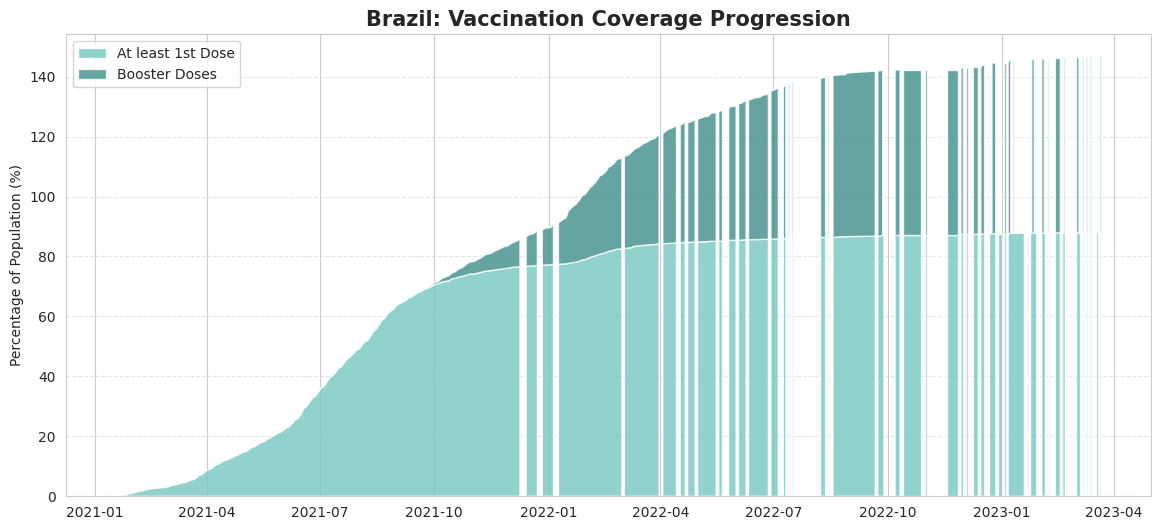

In [40]:
def plot_brazil_vaccination(df):
    plt.figure(figsize=(14, 6))

    plt.stackplot(df['date'],
                  df['people_vaccinated_per_hundred'],
                  df['total_boosters_per_hundred'],
                  labels=['At least 1st Dose', 'Booster Doses'],
                  colors=['#76c7c0', '#3e8e8a'], alpha=0.8)

    plt.title('Brazil: Vaccination Coverage Progression', fontsize=15, fontweight='bold')
    plt.ylabel('Percentage of Population (%)')
    plt.legend(loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

plot_brazil_vaccination(df_brazil)

## **8. Statistical Significance Testing**

In this section, we move beyond visual correlation to determine if our findings are statistically significant. We will focus on the relationship between Ageing (65+) and Mortality Rate.

### **8.1 - Hypothesis Testing: Age vs. Mortality**
- Null Hypothesis ($H_0$): There is no significant correlation between the percentage of the population over 65 and the mortality rate.
- Alternative Hypothesis ($H_1$): There is a significant positive correlation.Python

In [41]:
def calculate_statistical_significance(df, col1, col2):
    """
    Calculates Pearson Correlation and T-test for significance.
    """
    # Dropping NaNs for accurate calculation
    clean_data = df[[col1, col2]].dropna()
    x = clean_data[col1]
    y = clean_data[col2]

    # Pearson Correlation (r) and p-value
    r, p_value = stats.pearsonr(x, y)

    # Degrees of freedom
    n = len(clean_data)
    df_degrees = n - 2

    # T-Calculated
    t_calc = (r * np.sqrt(df_degrees)) / np.sqrt(1 - r**2)

    # T-Critical (95% confidence)
    t_crit = stats.t.ppf(1 - 0.025, df_degrees)

    print(f"--- Statistical Report: {col1} vs {col2} ---")
    print(f"Sample Size (n): {n}")
    print(f"Pearson Correlation (r): {r:.4f}")
    print(f"P-value: {p_value:.4e}")
    print(f"T-calculated: {t_calc:.4f}")
    print(f"T-critical (alpha=0.05): {t_crit:.4f}")

    if abs(t_calc) > t_crit:
        print("\n✅ RESULT: Statistically Significant. We reject the Null Hypothesis.")
    else:
        print("\n❌ RESULT: Not Statistically Significant. We fail to reject the Null Hypothesis.")

calculate_statistical_significance(df_countries, 'aged_65_older', 'total_deaths_per_million')

--- Statistical Report: aged_65_older vs total_deaths_per_million ---
Sample Size (n): 318060
Pearson Correlation (r): 0.5034
P-value: 0.0000e+00
T-calculated: 328.5267
T-critical (alpha=0.05): 1.9600

✅ RESULT: Statistically Significant. We reject the Null Hypothesis.


## **9. Executive Summary & Final Insights**

### **9.1 - Key Takeaways**

- Demographic Vulnerability: Our statistical test confirmed a significant positive correlation between elderly populations and mortality. This justifies targeted public health policies for aging nations.

- The Decoupling Phenomenon (Brazil): The time-series analysis reveals that while the Omicron variant led to a massive spike in cases, the mortality curve remained relatively flat. This is the data-driven proof of vaccine effectiveness in preventing severe cases.

- Socioeconomic Resilience: Interestingly, GDP per capita showed a lower correlation with mortality than demographic factors, suggesting that public health strategy and population age were more decisive than national wealth alone.

### **9.2 - Challenges & Technical Growth**

- Handling Asynchronous Reporting: Developed a logic to extract the "Latest Available Data" per country, preventing biases caused by irregular weekend reporting.

- Data Reliability: Filtered regional aggregates (OWID codes) to ensure 100% country-specific accuracy.

- Scalability: Built modular plotting functions that can be reused for any new metric with minimal code changes.